Cell 1: Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Verify TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


Cell 2: Load and Preprocess Data
We use the MNIST dataset for this example, converting the images to vectors and binarizing them (0 or 1) as standard RBMs expect binary inputs.

In [2]:
# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Flatten and normalize images to [0, 1]
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

# Binarize the inputs for the RBM
x_train = np.where(x_train > 0.5, 1.0, 0.0).astype('float32')
x_test = np.where(x_test > 0.5, 1.0, 0.0).astype('float32')

# Create a tf.data Dataset
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(10000).batch(batch_size)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Cell 3: Define the RBM in TensorFlow 2.0
Here we build the RBM using tf.Module and write the custom Contrastive Divergence (CD-1) step to update the visible/hidden biases and the weight matrix.

In [3]:
class RBM(tf.Module):
    def __init__(self, v_dim, h_dim):
        super(RBM, self).__init__()
        # Weight matrix between visible and hidden layer
        self.W = tf.Variable(tf.random.normal([v_dim, h_dim], stddev=0.1), name='weights')
        # Biases for visible and hidden layers
        self.vb = tf.Variable(tf.zeros([v_dim]), name='visible_bias')
        self.hb = tf.Variable(tf.zeros([h_dim]), name='hidden_bias')

    def sample_h_given_v(self, v):
        # p(h=1|v) = sigmoid(vW + hb)
        h_prob = tf.nn.sigmoid(tf.matmul(v, self.W) + self.hb)
        # Sample hidden units
        h_sample = tf.nn.relu(tf.sign(h_prob - tf.random.uniform(tf.shape(h_prob))))
        return h_prob, h_sample

    def sample_v_given_h(self, h):
        # p(v=1|h) = sigmoid(hW^T + vb)
        v_prob = tf.nn.sigmoid(tf.matmul(h, tf.transpose(self.W)) + self.vb)
        # Sample visible units
        v_sample = tf.nn.relu(tf.sign(v_prob - tf.random.uniform(tf.shape(v_prob))))
        return v_prob, v_sample

    @tf.function
    def cd1(self, v, lr=0.01):
        # Forward pass (Visible to Hidden)
        h0_prob, h0_sample = self.sample_h_given_v(v)

        # Reconstruction (Hidden to Visible)
        v1_prob, v1_sample = self.sample_v_given_h(h0_sample)

        # Second Forward pass (Reconstructed Visible to Hidden)
        h1_prob, h1_sample = self.sample_h_given_v(v1_sample)

        # Compute gradients
        positive_grad = tf.matmul(tf.transpose(v), h0_prob)
        negative_grad = tf.matmul(tf.transpose(v1_prob), h1_prob)

        # Update weights and biases
        batch_size_tf = tf.cast(tf.shape(v)[0], tf.float32)

        self.W.assign_add(lr * (positive_grad - negative_grad) / batch_size_tf)
        self.vb.assign_add(lr * tf.reduce_mean(v - v1_prob, axis=0))
        self.hb.assign_add(lr * tf.reduce_mean(h0_prob - h1_prob, axis=0))

        # Return Mean Squared Error for monitoring
        return tf.reduce_mean(tf.square(v - v1_prob))

Cell 4: Train the RBM

In [4]:
# Initialize Model
v_dim = 784  # 28x28 images
h_dim = 128  # Number of hidden units
rbm = RBM(v_dim, h_dim)

# Training loop
epochs = 10
learning_rate = 0.1

print("Training RBM...")
for epoch in range(epochs):
    epoch_error = 0.0
    steps = 0
    for batch in train_dataset:
        error = rbm.cd1(batch, lr=learning_rate)
        epoch_error += error
        steps += 1

    avg_error = epoch_error / steps
    print(f"Epoch: {epoch + 1:02d} | Reconstruction Error: {avg_error:.4f}")

Training RBM...
Epoch: 01 | Reconstruction Error: 0.0405
Epoch: 02 | Reconstruction Error: 0.0308
Epoch: 03 | Reconstruction Error: 0.0286
Epoch: 04 | Reconstruction Error: 0.0274
Epoch: 05 | Reconstruction Error: 0.0265
Epoch: 06 | Reconstruction Error: 0.0259
Epoch: 07 | Reconstruction Error: 0.0254
Epoch: 08 | Reconstruction Error: 0.0250
Epoch: 09 | Reconstruction Error: 0.0246
Epoch: 10 | Reconstruction Error: 0.0243


Cell 5: Plot Original and Reconstructed Images

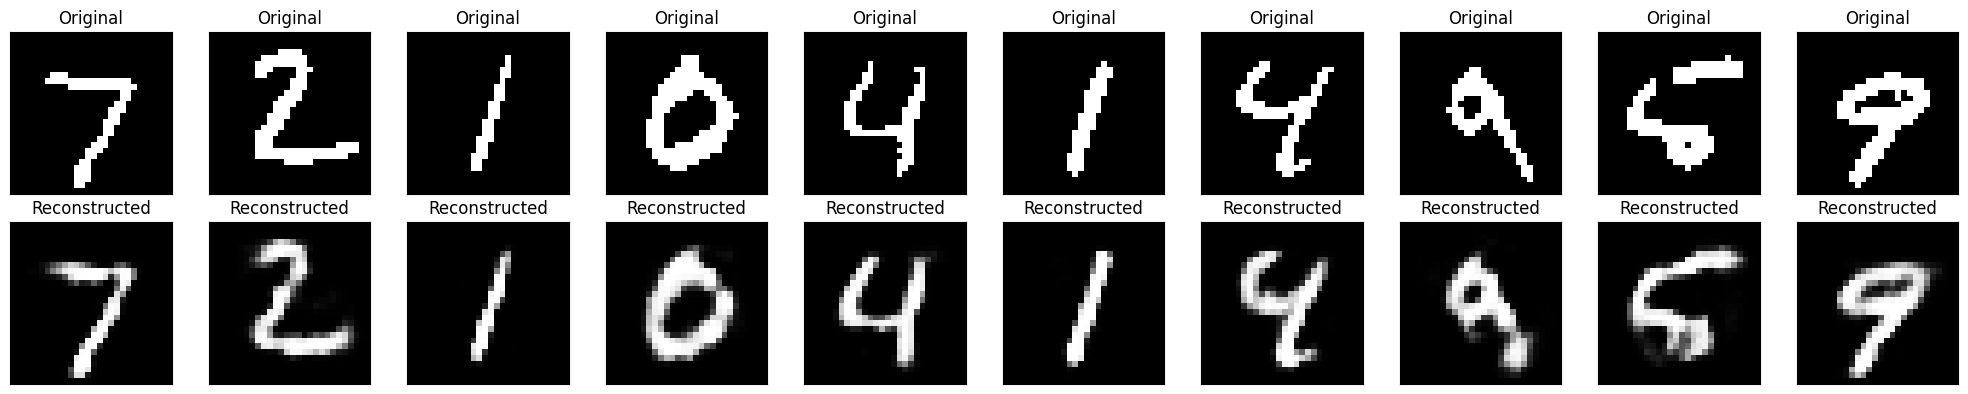

In [5]:
# Select the first 10 images from the test set
num_images = 10
test_images = x_test[:num_images]

# Pass the images through the RBM to reconstruct them
h_prob, h_sample = rbm.sample_h_given_v(test_images)
reconstructed_prob, reconstructed_sample = rbm.sample_v_given_h(h_sample)

# Plotting
plt.figure(figsize=(20, 4))
for i in range(num_images):
    # Display Original
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display Reconstruction
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed_prob[i].numpy().reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()